In [1]:
# my imports

%matplotlib notebook
import time
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter, MinuteLocator
import folium
from pymongo import MongoClient
import pandas as pd

from collections import defaultdict
from statistics import mean

from datetime import datetime

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-o0kxhnn7 because the default path (/home/student/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



First I plot 2 graphs, Violations vs Arrival Time and Speed vs Arrival Time.

For the Violations vs Arrival Time graph, I plot the number of violations recorded at each timestamp (or grouped arrival time) on the y-axis, against the corresponding arrival times on the x-axis. The data points are connected with a line to show the trend over time, and markers indicate the exact counts at each time point. 

For the Speed vs Arrival Time graph, I plot the average violated speeds at each arrival time. The y-axis shows the average speed in km/h, and the x-axis again represents the arrival times. I use a distinct color (orange) and 'x' markers connected by lines to differentiate it from the violations graph. I also annotate the graph to highlight the maximum, minimum and average speeds, providing immediate visual cues on speed extremes.

Analysis of graphs:

I chose to add min and max violations to highlight critical extremes. By doing so, the graphs reveal several notable spikes in both the number of violations and average violated speeds at specific arrival times. These spikes represent moments where there was a sudden surge in speeding behavior or a burst of recorded violations. Such spikes may correspond to periods of fluctuating traffic conditions, like vehicles accelerating after congestion or localized changes in enforcement intensity. By understanding the data here, we can identify critical periods when speeding violations surge, enabling targeted deployment of traffic enforcement resources to those peak times. This insight helps in designing more effective traffic safety interventions, such as adjusting speed limits or increasing patrol presence during high-risk intervals. Additionally, analyzing these spikes allows us to recognize patterns in driver behavior and environmental factors contributing to violations, ultimately supporting data-driven decisions to enhance road safety and reduce accidents.


<IPython.core.display.Javascript object>


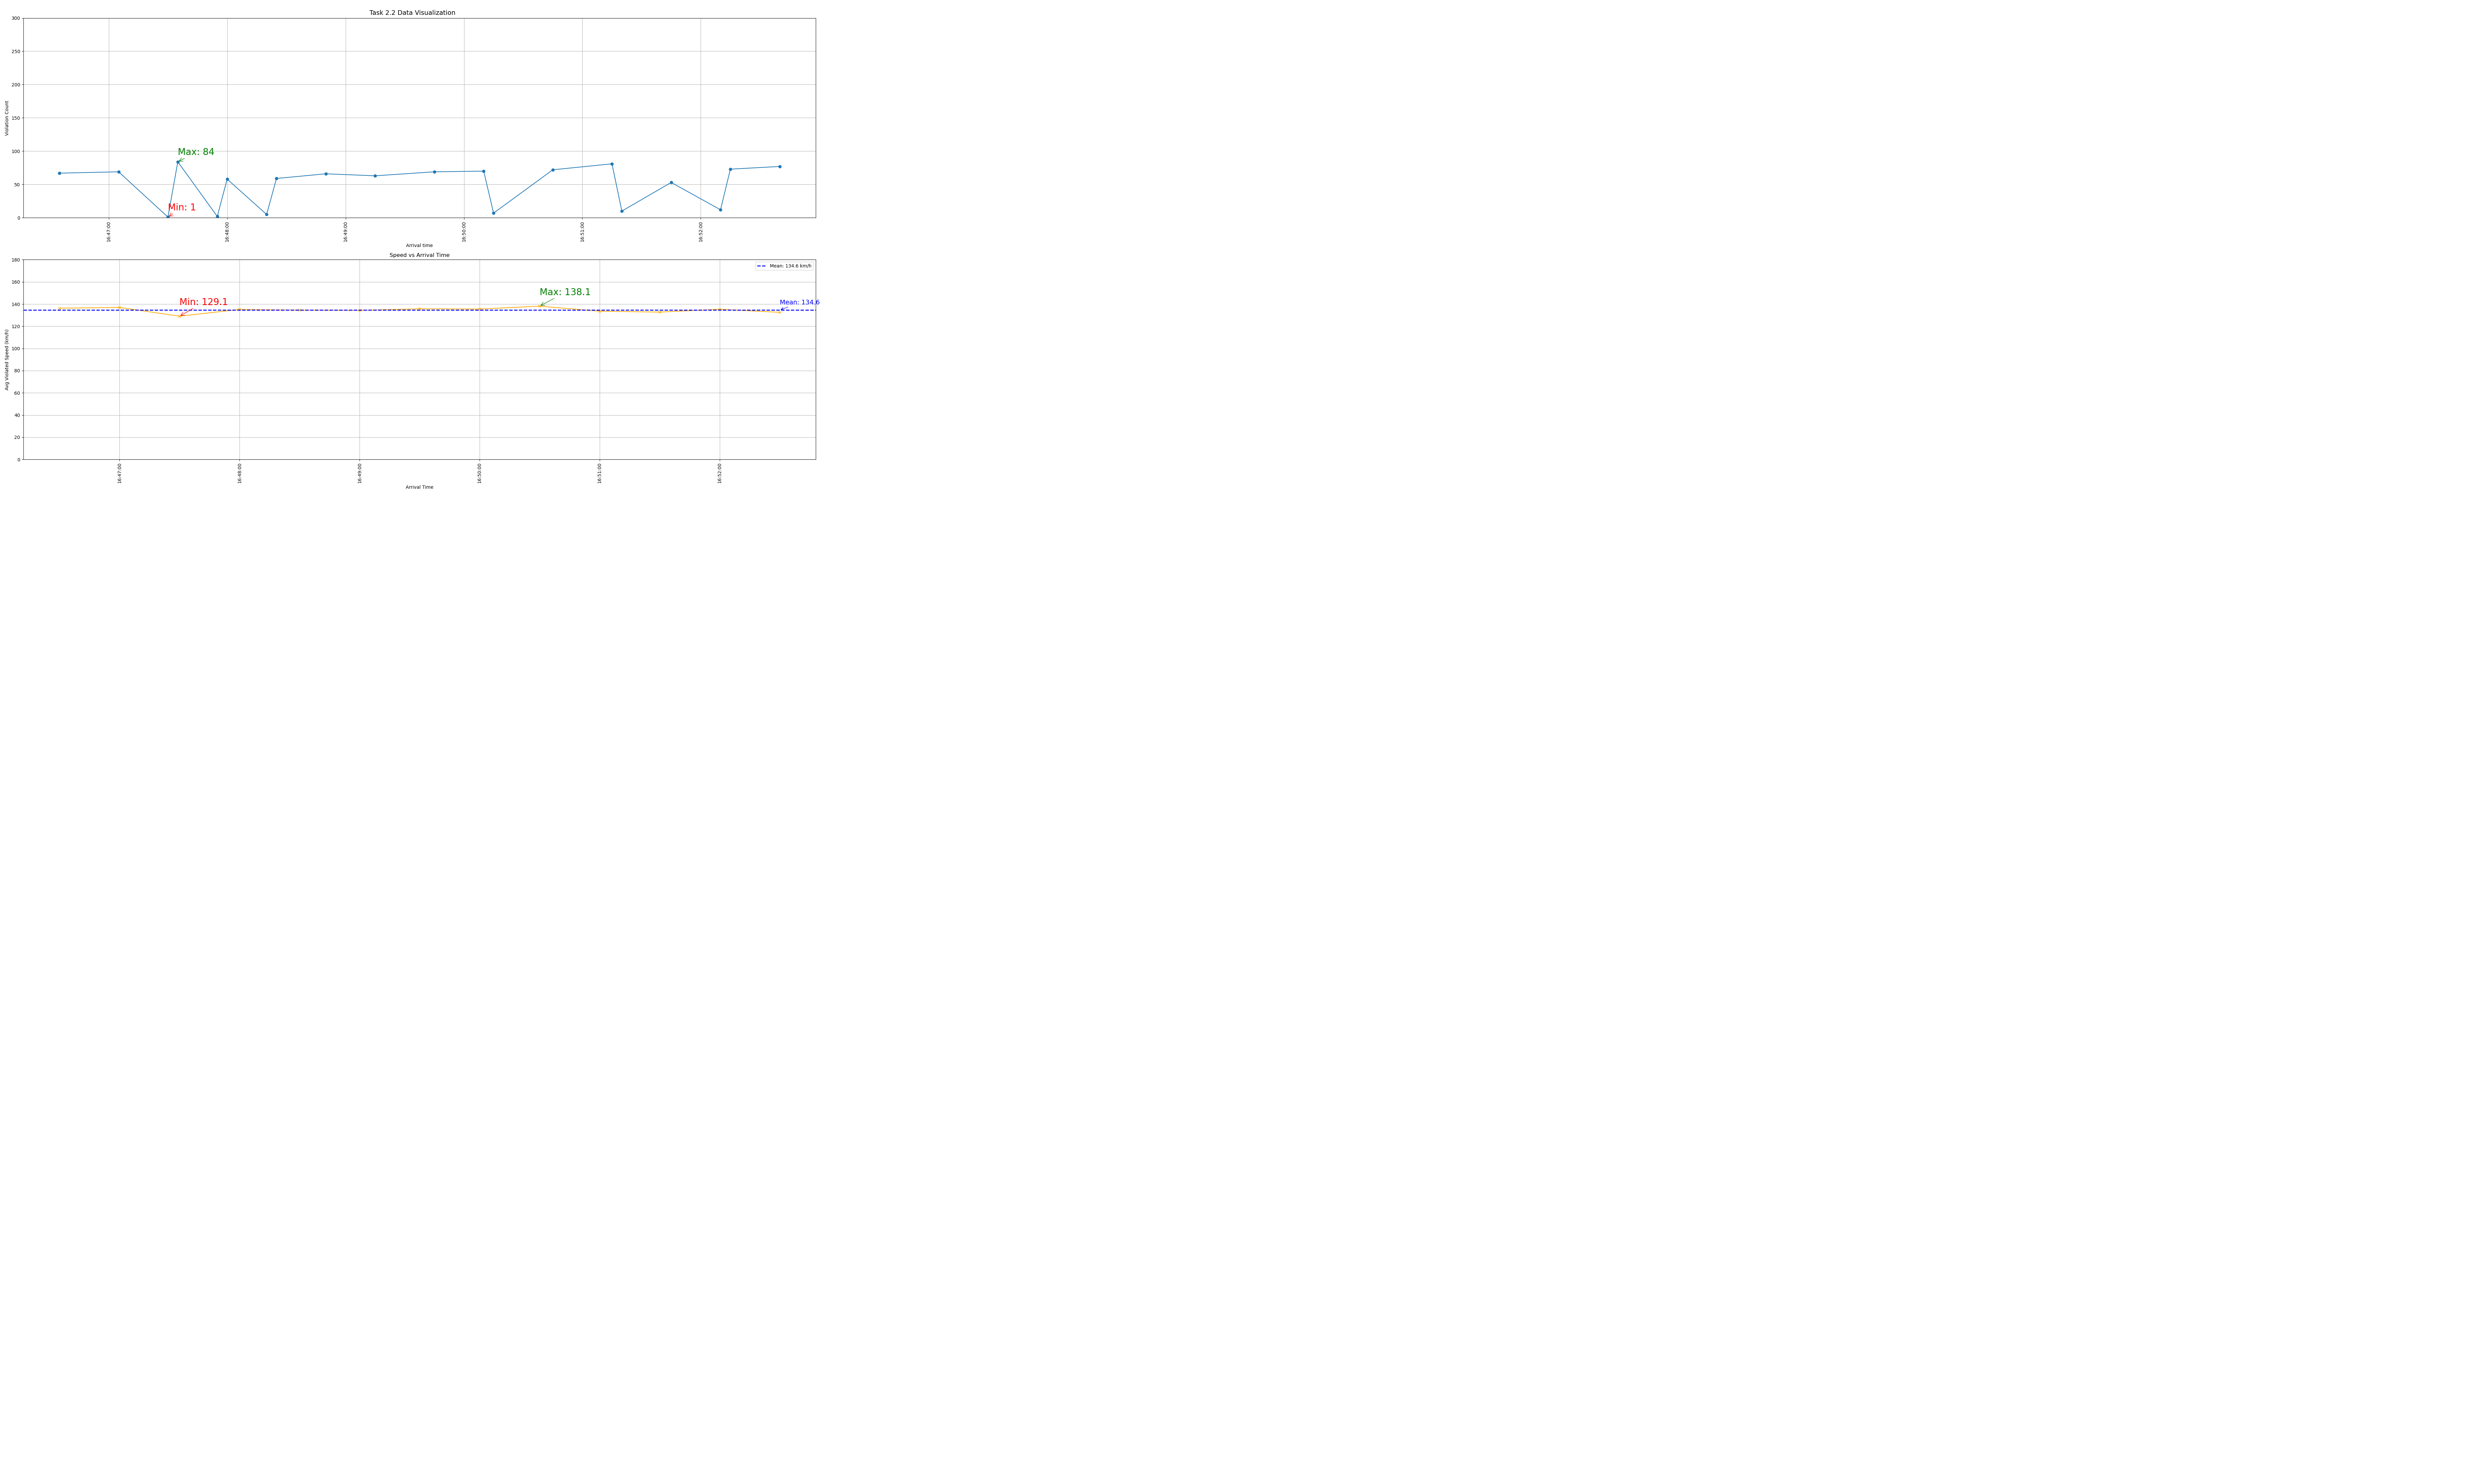

/tmp/ipykernel_63704/1233470461.py:161: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  fig.tight_layout()
/tmp/ipykernel_63704/1233470461.py:162: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  fig.canvas.draw()
/tmp/ipykernel_63704/1233470461.py:112: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.tight_layout()
/tmp/ipykernel_63704/1233470461.py:113: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's interv

In [ ]:
def init_plots():
    """
    Initialize figure with 2 subplots:
    1. Violations vs Arrival Time
    2. Speed vs Arrival Time
   
    """
    try:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 15), sharex=False)
       

        # x-axis formatting(time)
        time_formatter = mdates.DateFormatter('%H:%M:%S')
        time_locator = mdates.AutoDateLocator(maxticks=10)

        # first plot: violations over arrival time
        ax1.set_title("Violations vs Arrival Time")
        ax1.set_ylabel("Violation Count")
        ax1.set_xlabel("Arrival Time")
        ax1.grid(True)
        ax1.xaxis.set_major_formatter(time_formatter)
        ax1.xaxis.set_major_locator(time_locator)
        ax1.tick_params(axis='x', rotation=90)
        ax1.set_ylim(0, 300)

        # second plot: speed over arrival time
        ax2.set_title("Speed vs Arrival Time")
        ax2.set_xlabel("Arrival Time")
        ax2.set_ylabel("Speed (km/h)")
        ax2.grid(True)
        ax2.xaxis.set_major_formatter(time_formatter)
        ax2.xaxis.set_major_locator(time_locator)
        ax2.tick_params(axis='x', rotation=90)
        ax2.set_ylim(0, 180)

        plt.subplots_adjust(hspace=0.5, bottom=0.08)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.ion()
        fig.show()
        fig.canvas.draw()
        
        return fig, (ax1, ax2)
    
    except Exception as e:
        print(f"Error initializing plots: {e}")
        return None, (None, None)
    
    
def extract_time_added_counts(df):
    """
    Extracts and counts the number of violations added at each 30-second interval(limit to latest 20 intervals)

    """
    all_times = []
    for violation_list in df['violations']:
        if isinstance(violation_list, list):
            for v in violation_list:
                ta = v.get('time_added')
                if ta:
                    all_times.append(ta)

    # Convert to datetime
    times = pd.to_datetime(all_times)

    # floor to nearest 30-second bucket
    times_30s = pd.Series(times).dt.floor('5S')

    # count violations per 30-second interval
    counts = times_30s.value_counts().sort_index()

    # only get latest 20 intervals
    counts = counts.tail(20)

    return counts
    
    
def plot_violations(ax, counts, fig):
    """
    Plots violation counts over time on the given axis.

    """
    # clear at the start of every refresh
    ax.clear()
    ax.plot(counts.index, counts.values, marker='o', linestyle='-')

    ax.set_ylabel("Violation Count")
    ax.set_xlabel("Arrival time")
    ax.grid(True)
    ax.set_ylim(0, max(300, counts.max() + 10))

    # format the x-axis to show readable timestamps
    time_formatter = mdates.DateFormatter('%H:%M:%S')
    time_locator = mdates.AutoDateLocator(maxticks=10)
    ax.xaxis.set_major_formatter(time_formatter)
    ax.xaxis.set_major_locator(time_locator)
    ax.tick_params(axis='x', rotation=90)
    
    # Annotate maximum and minimum points
    max_time = counts.idxmax()
    max_val = counts.max()
    min_time = counts.idxmin()
    min_val = counts.min()

    # this labels the max and min violations count at time range shown on plot
    ax.annotate(f'Max: {max_val}', xy=(max_time, max_val), xytext=(max_time, max_val + 10),
                arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=20)

    ax.annotate(f'Min: {min_val}', xy=(min_time, min_val), xytext=(min_time, min_val + 10),
                arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=20)

    # redraw and adjust the spacings
    plt.tight_layout()
    fig.tight_layout()
    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.draw()
    plt.pause(0.01)
    
def plot_speed(ax, avg_speeds, fig):
    """
    Plots average violated speeds over time on the given axis.

    """
    # clear at the start of every refresh
    ax.clear()
    ax.plot(avg_speeds.index, avg_speeds.values, marker='x', linestyle='-', color='orange')
    ax.set_title("Speed vs Arrival Time")
    ax.set_ylabel("Avg Violated Speed (km/h)")
    ax.set_xlabel("Arrival Time")
    ax.grid(True)
    ax.set_ylim(0, max(180, avg_speeds.max() + 10))

    # x axis formatting
    time_formatter = mdates.DateFormatter('%H:%M:%S')
    time_locator = mdates.AutoDateLocator(maxticks=10)
    ax.xaxis.set_major_formatter(time_formatter)
    ax.xaxis.set_major_locator(time_locator)
    ax.tick_params(axis='x', rotation=90)
    
    # for annotate max and min points
    max_time = avg_speeds.idxmax()
    max_val = avg_speeds.max()
    min_time = avg_speeds.idxmin()
    min_val = avg_speeds.min()

    ax.annotate(f'Max: {max_val:.1f}', xy=(max_time, max_val), xytext=(max_time, max_val + 10),
                arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=20)

    ax.annotate(f'Min: {min_val:.1f}', xy=(min_time, min_val), xytext=(min_time, min_val + 10),
                arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=20)
    
    # also plot the average speeds
    mean_val = avg_speeds.mean()
    ax.axhline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f} km/h')
    ax.annotate(f'Mean: {mean_val:.1f}', xy=(avg_speeds.index[-1], mean_val), xytext=(avg_speeds.index[-1], mean_val + 5),
                arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=14)

    # add legend
    ax.legend()
    # redraw and adjust spacings
    fig.tight_layout()
    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(0.01)
    
    
def extract_avg_speed_over_time(df):
    """
    Extracts average violated speed for each 30-second interval.

    """
    speeds = []
    times = []

    # loop through the violations list, get all the violation speeds and time of processing
    for violation_list in df['violations']:
        if isinstance(violation_list, list):
            for v in violation_list:
                ta = v.get('time_added')
                speed = v.get('violated_speed')
                if ta and speed is not None:
                    try:
                        speed_val = float(speed)
                        speeds.append(speed_val)
                        times.append(ta)
                    except:
                        continue  # skip invalid entries

    # convert time_added to datetime
    time_series = pd.to_datetime(times).floor('30S')
    df_speeds = pd.DataFrame({'time': time_series, 'speed': speeds})

    # group by time and average
    avg_speeds = df_speeds.groupby('time')['speed'].mean().sort_index()

    # keep  only the latest 20 entries
    avg_speeds = avg_speeds.tail(20)

    return avg_speeds

if __name__ == '__main__':
    
    # connect to mongo
    host_ip = "10.192.101.151"
    client = MongoClient(host=host_ip, port=27017)
    db = client["fit3182_a2_db_test_3"]
    violation_collection = db["violations_test_17"]

    fig, ax = init_plots()

    # loop to redraw graph 
    while True:
        
        data = list(violation_collection.find())
        df = pd.DataFrame(data)

        if df.empty or 'violations' not in df.columns:
            print("No violation data found, waiting...")
            time.sleep(5)
            continue

        counts = extract_time_added_counts(df)
        avg_speeds = extract_avg_speed_over_time(df)


        # plot my graphs
        plot_violations(ax[0], counts, fig)
        plot_speed(ax[1], avg_speeds, fig)

        time.sleep(5)
        
    client.close()
        
    

Map Visualization

For this, we first choose a day to find the distribution of traffic violations along a position on the highway. By filtering the violations data for the selected date, we aggregate the counts of different types of violations per camera location or camera pairs. This allows us to visualize hotspots on an interactive map. 

Observations:
The blue markers indicate locations where instantaneous speed violations were recorded. The size and popup information help identify cameras with frequent violations. If the marker is red, this means that theres a violation hotspot.
We may see a spike in speeding during holidays when everyone is rushing to travel.



In [2]:


def plot_violations_hotspots(db, date_only, threshold = 50):
    """
    Generate a Folium map visualizing traffic violation hotspots for a given date.

    """
    # get all violation docs for the date
    violations_list = list(db["violations_test_17"].find({"violation_date": date_only}))
    if not violations_list:
        print(f"No violations found for date {date_only}")
        return None

    # dictionary for instant and average speed violations(to hold count of each violations)
    instant_speeds = {}
    avg_speeds = {}

    # get the camera locations
    cameras = list(db["cameras"].find())
    camera_positions = {c["camera_id"]: (c["latitude"], c["longitude"]) for c in cameras}
    
    # get and count the violations for a day
    for doc in violations_list:
        for v in doc.get("violations", []):
            vtype = v.get("violation_type")
            if vtype == "instantaneous_speed_violation":
                cam_id = v.get("camera_id")
                speed = v.get("violated_speed")
                instant_speeds.setdefault(cam_id, []).append(speed)
            elif vtype == "average_speed_violation":
               
                cam1 = v.get("camera_1")
                cam2 = v.get("camera_2")
                speed = v.get("violated_speed")
                # sort tuple for consistency
                pair = tuple(sorted((cam1, cam2)))
                avg_speeds.setdefault(pair, []).append(speed)

    # create folium map centered around all cameras
    avg_lat = mean([pos[0] for pos in camera_positions.values()])
    avg_lon = mean([pos[1] for pos in camera_positions.values()])
    fmap = folium.Map(location=[avg_lat, avg_lon], zoom_start=12)

    # add checkpoints for each camera (instantaneous violations)
    for cam_id, pos in camera_positions.items():
        speeds = instant_speeds.get(cam_id, [])
        count = len(speeds)
        avg_speed = round(mean(speeds), 2) if speeds else 0
        marker_color = 'red' if count > threshold else 'blue'

        popup_text = (f"Camera {cam_id}\n"
                      f"Total Instantaneous Violations: {count}\n"
                      f"Avg Violated Speed: {avg_speed} km/h")
        folium.Marker(
            location=pos,
            popup=popup_text,
            icon=folium.Icon(color=marker_color, icon='info-sign')
        ).add_to(fmap)



    # add circles and lines between cameras for average speed violations
    
    for (cam1, cam2), speeds in avg_speeds.items():
        pos1 = camera_positions.get(cam1)
        pos2 = camera_positions.get(cam2)
        
        # if i can't get my camera position i skip
        if not pos1 or not pos2:
            continue  

        count = len(speeds)
        avg_speed = round(mean(speeds), 2)

        # midpoint for circle
        mid_lat = (pos1[0] + pos2[0]) / 2
        mid_lon = (pos1[1] + pos2[1]) / 2

        # add polyline between cameras
        folium.PolyLine(
            locations=[pos1, pos2],
            color='green',
            weight=6,
            popup=f"Avg Speed Violations between Cam {cam1} & {cam2}: {count}\nAvg Violated Speed: {avg_speed} km/h"
        ).add_to(fmap)

        # add semi-transparent circle at midpoint for hotspot
        folium.CircleMarker(
            location=[mid_lat, mid_lon],
            radius=15,
            color='red',
            fill=True,
            fill_opacity=0.4,
            popup=(f"Avg Speed Violations between Cam {cam1} & {cam2}\n"
                   f"Count: {count}\n"
                   f"Avg Violated Speed: {avg_speed} km/h")
        ).add_to(fmap)

    return fmap
    
    
if __name__ == "__main__":
    
    host_ip = "10.192.101.151"
    db_name = "fit3182_a2_db_test_2"
    
    client = MongoClient( host=f'{host_ip}',
            port=27017)
    db = client[db_name]
    
    # here i put my date to check for hotspots
    date_to_check = "2024-01-01"
    
    # plot my map and display
    fomap = plot_violations_hotspots(db, date_to_check)
    display(fomap)
    
    # close 
    client.close()
    
    
    
    
    
    
